In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path
from read_roi import read_roi_zip
from collections import OrderedDict, Counter
import math
import PIL
from PIL import Image
from PIL.TiffTags import TAGS
import tkinter as tk
from tkinter import filedialog
import seaborn as sns

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import csv
import pandas as pd
from pathlib import Path
from read_roi import read_roi_zip
from collections import OrderedDict, Counter
import math
import PIL
from PIL import Image
from PIL.TiffTags import TAGS
import tkinter as tk
from tkinter import filedialog
import seaborn as sns

# Read, format and save raw data from ROIs #

In [3]:
askdirectory = filedialog.askdirectory() # show an "Open" dialog box and return the path to the selected file
path = Path(askdirectory)
path #path doesn't care windows, linux etc, should work to direct

WindowsPath('D:/Dropbox/Summer2021 Undergrads/MTdynamics/2020-09-10_CH12_tub06uM_typeWT_DCX050nM')

In [4]:
tubulin = '[Tubulin] ' r'$(\mu M)$'#python can read latec code, if put r'$ signs inside the quotations, anything you write inside that it will read as laytex, easier to writ the greek alphabet with \letter
tub = 'tub'

DCXconc = '[DCX] ' r'$(n M)$'
DCX = 'DCX'

investigator = 'Sofia'
#this makes easeier later to access declared name with minimal length issues

In [9]:
dateloc = str(path).rfind("202")#within file name there is a date,this finds that date
date = str(path)[dateloc : dateloc+10] #keep the string till 10 digets after that date

folders = [x for x in path.iterdir() if x.is_dir()] #here gave it the same parent directory that stores the names
folders = [i for i in folders if (str(i)[-7:] == 'results') == True] # assumes that frame analyzer was run first so the data containing folders have results added
ch = [] #Ch stands for channels, first number stands for which microscope holder, second number stands for channel
conc_tub = []
conc_DCX = []
DCX_type = [] #store these parameters of each folder, for this list wt, etc

for i in folders: #goes through names and finds each string and store th at plus the specific data associated with the name in each folder (following data captured by splice, becuase of splicing specificity needs to be very specifidc with namein)
    CHloc = str(i).find("CH")
    tubloc = str(i).rfind(tub)
    DCXloc = str(i).rfind(DCX)
    dcxtype = str(i).rfind("type")
    ch = ch + [str(i)[CHloc+2:CHloc+4]]
    conc_tub = conc_tub + [(str(i)[tubloc+3:tubloc+5])]
    conc_DCX = conc_DCX + [(str(i)[DCXloc+3:DCXloc+6])]
    DCX_type = DCX_type + [(str(i)[dcxtype+4:DCXloc-1])]

date,ch, conc_tub, conc_DCX, DCX_type

('2020-09-10', ['12'], ['06'], ['050'], ['WT'])

In [10]:
tub_conc =  [float(i) for i in conc_tub]
DCX_conc =  [float(i) for i in conc_DCX]
frame_analyzer = pd.read_csv(path/'frame_rates_avg.csv',sep=',')
pixel =  0.107 #0.107 #0.0633 107nm for T2 the second microscope, 63nm for T1 the first microscope
folders

[WindowsPath('D:/Dropbox/Summer2021 Undergrads/MTdynamics/2020-09-10_CH12_tub06uM_typeWT_DCX050nM/CH12_tub06uM_typeWT_DCX050nM-results')]

In [11]:
#frame_analyzer = frame_analyzer.iloc[[1,3]].reset_index()
frame_analyzer

,Directory,Mean,SD,Frames,Outliers,MeanWOutliers,SDWOutliers
0,C:\Users\callu\Dropbox\Summer2021 Undergrads\M...,5.04,0.02,400,1,12.96,158.14


In [12]:
def open_roi_poly(k,name): #for the multidot lines, only works for 3 dots, k is number and name is name file
    roi_path = folders[k]/(name)#access ROI file

    roi_data = read_roi_zip(roi_path) #comes from hadim scrpt
    roi_df = pd.DataFrame(columns=['Track ID','x1','x2','x3','y1','y2','y3'])#makes data frame column names
    for key in roi_data: #input coordinates into correct colns
        roi_df = roi_df.append({'Track ID': roi_data[key]['name'],'x1': roi_data[key]['x'][0],'x2': roi_data[key]['x'][1],'x3': roi_data[key]['x'][2],'y1': roi_data[key]['y'][0],'y2': roi_data[key]['y'][1],'y3': roi_data[key]['y'][2]}, ignore_index=True)
    return roi_df #outputs datae frame

def open_roi_line(k,name): #exact same but but finding data by name instead of index
    roi_path = folders[k]/(name)

    roi_data = read_roi_zip(roi_path)
    roi_df = pd.DataFrame(columns=['Track ID','x1','x2','y1','y2'])
    for key in roi_data:
        roi_df = roi_df.append({'Track ID': roi_data[key]['name'],'x1': roi_data[key]['x1'],'x2': roi_data[key]['x2'],'y1': roi_data[key]['y1'],'y2': roi_data[key]['y2']}, ignore_index=True)
    return roi_df

In [13]:
Length = 'Length ' r'$(\mu m)$' # name +units
Lifetime = 'Lifetime ' r'$(min)$'
GrowthRate = 'Growth Rate ' r'$(\mu m / min)$'
TimeToNucleate = 'Time to Nucleate ' r'$(min)$'
ShrinkageLength = 'Shrink Length ' r'$(\mu m)$'
ShrinkageLifetime = 'Shrink Lifetime ' r'$(min)$'
ShrinkageRate = 'Shrink Rate ' r'$(\mu m / min)$'
poly_parameter_names = (Length,Lifetime,GrowthRate,TimeToNucleate)
line_parameter_names = (Length,Lifetime,GrowthRate,TimeToNucleate,ShrinkageLength,ShrinkageLifetime,ShrinkageRate)

In [14]:
def poly_dynamics(k):#so for folder #x, look for 
        
    data = open_roi_poly(k,'kymoslopes.zip') 
    supp = open_roi_line(k,'start.zip') 
    
    spf = frame_analyzer['Mean'][k]; #access same row
    frames = frame_analyzer['Frames'][k]-2 #conrirms the nyumber of freames though always same 
    
    suppn = len(supp)
    start = sum(abs(supp['y2']-supp['y1']))/suppn;#looking at average of start to give start time
    
    n = len(data) # kymographs so that each kymo will have all that data
    pre_df = {'Date': np.full((n), date), 'Investigator': np.full((n), investigator),
              'CH': np.full((n), ch[k]),tubulin: np.full((n), tub_conc[k]),DCXconc: np.full((n), DCX_conc[k])} #delaring the colns
    df = pd.DataFrame(pre_df) #initialize data frame with those colns
    
    df[Length] = abs((data['x2']-data['x1'])*pixel) #appending a length coln by subtracting x then muliply by pixels so in microns
    
    data[Lifetime] = abs((data['y2']-data['y1'])*spf/60) # length in minutes coln append
    df[Lifetime] = data[[Lifetime,'y2']].apply(lambda x: x[Lifetime] if x['y2'] < frames-2 else np.NaN, axis=1) #filtering out if lifetime was longer than the movie filter it out
    df[Lifetime] = data[[Lifetime,'y2']].apply(lambda x: x[Lifetime] if x[Lifetime] != 0 else np.NaN, axis=1) #if the lifetime was zero deltee it
    
    df[GrowthRate] = df[Length]/df[Lifetime] # append growth based on length divided by time period
    df[GrowthRate] = df[GrowthRate].apply(lambda x: x if x <= 5 else np.NAN )#filter if smaller than 5
    
    df[TimeToNucleate] = (data['y1']-start)*spf/60 #access first time spot then subtract start and convert to min
    
    df[ShrinkageLength] = abs((data['x3']-data['x2'])*pixel) #same thing for growth but shrinkage
    df[ShrinkageLifetime] = abs((data['y3']-data['y2'])*spf/60)
    df[ShrinkageLifetime] = df[ShrinkageLifetime].apply(lambda x: np.NAN if x == 0 else x)
    df[ShrinkageRate] = df[ShrinkageLength]/df[ShrinkageLifetime] #same thing as for growth ratye
    
    df.loc[pd.isnull(df[GrowthRate]), #if no growth rate make everything nan
           [Length,Lifetime,TimeToNucleate,ShrinkageLength,ShrinkageLifetime,ShrinkageRate]] = np.NaN
    
    df['Rescues'] = df[[Length,ShrinkageLength]].apply(lambda x: True if abs(x[Length]-x[ShrinkageLength]) > pixel*5 else False, axis=1) #it subtracts wwhere the mt starts and the catastrophe ended, if totally aligned then no rescue. need to be misaligbned by at least 5 pixles so know no tmeasure issue
    
    df['DCX Type'] = DCX_type[k]
        
    return df #resturns total datea

def line_dynamics(k): #same idea but for single lines instead triangles, never gets used now
        
    data = open_roi_line(k,'kymoslopes.zip')
    #data_even = data.iloc[::2].reset_index()
    #data_odd = data.iloc[1::2].reset_index()
    data_even = data
    data_odd = data
    
    supp = open_roi_line(k,'start.zip')
    
    spf = frame_analyzer['Mean'][k];
    frames = frame_analyzer['Frames'][k]-2
    
    suppn = len(supp)
    start = sum(abs(supp['y2']-supp['y1']))/suppn;
    
    n = len(data_even)
    pre_df = {'Date': np.full((n), date),'CH': np.full((n), ch[k]),'Concentration ' r'$(\mu M)$': np.full((n), conc[k])}
    df = pd.DataFrame(pre_df) 
    
    data_even[Length] = abs((data_even['x2']-data_even['x1'])*pixel)
    data_even[Lifetime] = abs((data_even['y2']-data_even['y1'])*spf/60)
    df[GrowthRate] = data_even[Length]/data_even[Lifetime]
    df[GrowthRate] = df[GrowthRate].apply(lambda x: x if x <= 5 else np.NaN )
    
    data[Lifetime] = abs((data_odd['y2']-data_odd['y1'])*spf/60)
    df[Lifetime] = data[[Lifetime,'y2']].apply(lambda x: x[Lifetime] if x['y2'] < frames else np.NaN, axis=1)
    
    df[Length] = df[GrowthRate]*df[Lifetime]
    
    df[TimeToNucleate] = ((data_odd[['y1','y2']].min(axis=1))-start)*spf/60
    
    df.loc[pd.isnull(df[GrowthRate]), [Length,Lifetime,TimeToNucleate]] = np.NaN
    
    df = df[['Date','CH','Concentration ' r'$(\mu M)$',Length,Lifetime,GrowthRate,TimeToNucleate]]
        
    return df

In [15]:
path.parents[0] #remind of parent directory, but inpinciple can be any directory where you want to store data, this just easier

WindowsPath('D:/Dropbox/Summer2021 Undergrads/MTdynamics')

In [16]:
newdirectory = str(path.parents[0])+'//callum_kymo_data' #bc stareted in summer 2020, can choose a name that I wan, after I run can delte with own folder anem, 
newmydir = Path(newdirectory)
newmydir.mkdir(exist_ok=True)

In [17]:
df = poly_dynamics(0)
for i in range(1,len(ch)):
    df0 = poly_dynamics(i)
    df = df.append(df0, ignore_index=True)

df.to_csv(path/(investigator+'_'+date +'.csv'), encoding='utf-8', index=False)
df.to_csv(newmydir/(investigator+'_'+date+'.csv'), encoding='utf-8', index=False)
df

,Date,Investigator,CH,[Tubulin] $(\mu M)$,[DCX] $(n M)$,Length $(\mu m)$,Lifetime $(min)$,Growth Rate $(\mu m / min)$,Time to Nucleate $(min)$,Shrink Length $(\mu m)$,Shrink Lifetime $(min)$,Shrink Rate $(\mu m / min)$,Rescues,DCX Type
0,2020-09-10,Sofia,12,6.0,50.0,3.905501,8.652000,0.451399,0.280,1.676334,1.120001,1.496726,True,WT
1,2020-09-10,Sofia,12,6.0,50.0,6.919334,21.461999,0.322399,0.630,3.727167,1.764000,2.112906,True,WT
2,2020-09-10,Sofia,12,6.0,50.0,8.938958,29.980999,0.298154,0.301,3.816333,0.140002,27.259192,True,WT
3,2020-09-10,Sofia,12,6.0,50.0,4.743667,10.640000,0.445833,0.518,1.587167,0.853999,1.858511,True,WT
4,2020-09-10,Sofia,12,6.0,50.0,3.785125,8.169000,0.463352,0.427,2.400812,1.764000,1.361005,True,WT
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
65,2020-09-10,Sofia,12,6.0,50.0,2.247000,9.100000,0.246923,3.234,1.070000,0.896000,1.194196,True,WT
66,2020-09-10,Sofia,12,6.0,50.0,0.356667,1.344000,0.265377,0.756,0.321000,0.042000,7.642857,False,WT
67,2020-09-10,Sofia,12,6.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,WT
68,2020-09-10,Sofia,12,6.0,50.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False,WT


In [18]:
dfmean = df.groupby('CH').mean()
#dfmean.to_csv(path/(date+'_0_mean.csv'), encoding='utf-8', index=False)
dfmean

,[Tubulin] $(\mu M)$,[DCX] $(n M)$,Length $(\mu m)$,Lifetime $(min)$,Growth Rate $(\mu m / min)$,Time to Nucleate $(min)$,Shrink Length $(\mu m)$,Shrink Lifetime $(min)$,Shrink Rate $(\mu m / min)$,Rescues
CH,,,,,,,,,,
12,6.0,50.0,4.843053,12.746838,0.388411,1.970769,1.828157,1.195923,4.397487,0.814286


In [19]:
dfstd = df.groupby('CH').std()
#dfstd.to_csv(path/(date+'_0_std.csv'), encoding='utf-8', index=False)
dfstd

,[Tubulin] $(\mu M)$,[DCX] $(n M)$,Length $(\mu m)$,Lifetime $(min)$,Growth Rate $(\mu m / min)$,Time to Nucleate $(min)$,Shrink Length $(\mu m)$,Shrink Lifetime $(min)$,Shrink Rate $(\mu m / min)$,Rescues
CH,,,,,,,,,,
12,0.0,0.0,2.436853,6.636847,0.073972,2.443682,0.978536,0.996567,8.567207,0.391684


# Preliminary plot Histograms #

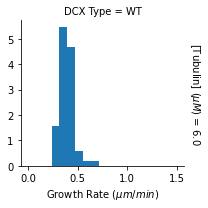

In [20]:
g = sns.FacetGrid(df, row=tubulin, col='DCX Type', margin_titles=True)
bins = np.linspace(0, 1.5, 20)
g.map(plt.hist, GrowthRate, bins=bins, density=True)

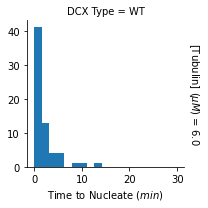

In [21]:
g = sns.FacetGrid(df, row=tubulin, col="DCX Type", margin_titles=True)
bins = np.linspace(0, 30, 20)
g.map(plt.hist, TimeToNucleate, bins=bins)

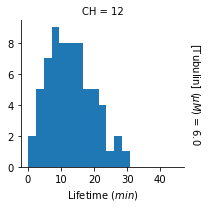

In [22]:
g = sns.FacetGrid(df, row=tubulin, col="CH", margin_titles=True)
bins = np.linspace(0, 45, 20)
g.map(plt.hist, Lifetime, bins=bins)

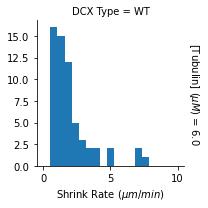

In [23]:
g = sns.FacetGrid(df, row=tubulin, col="DCX Type", margin_titles=True)
bins = np.linspace(0, 10, 20)
g.map(plt.hist, ShrinkageRate, bins=bins)